## Install & Import

In [1]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy scipy --quiet

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score, balanced_accuracy_score)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import wilcoxon

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn xgboost

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/pima-indians-diabetes.csv")


In [ ]:
df.describe()


,x1,x2,x3,x4,x5,x6,x7,x8,Class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# ── ACTUAL DATA LOADING ───────────────────────────────────────────────────
df = pd.read_csv("/content/drive/MyDrive/Dataset/pima-indians-diabetes.csv")

X = df.drop('Class', axis=1)

# Integer-encode labels
le = LabelEncoder()
y = pd.Series(le.fit_transform(df['Class']), name='Class')
class_names = list(le.classes_)

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Classes: {class_names}')
print(f'Class distribution:')
print(pd.Series(le.inverse_transform(y)).value_counts())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set: {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Testing set: {X_test.shape[0]} samples, {X_test.shape[1]} features')

# ── Feature importance for reference / display only ───────────────────────
# NOTE: top_features below is computed on the training dataset for display
# purposes ONLY.  All CV functions below recompute feature importance
# INSIDE each training fold to avoid feature-selection data leakage.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
importances = rf_selector.feature_importances_
top_features = X_train.columns[np.argsort(importances)[-10:]].tolist()

print(f'\nReference top features (train-data, display only): {top_features}')
print('(All CV runs recompute feature selection inside each fold.)')


Dataset: 768 samples, 8 features
Classes: [np.int64(0), np.int64(1)]
Class distribution:
0    500
1    268
Name: count, dtype: int64

Training set: 614 samples, 8 features
Testing set: 154 samples, 8 features

Reference top features (train-data, display only): ['x4', 'x5', 'x1', 'x3', 'x7', 'x8', 'x6', 'x2']
(All CV runs recompute feature selection inside each fold.)


## Shared Helper Functions

In [6]:
def medoid_of_group(X_group):
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=42):
    """
    Feature selection performed INSIDE a CV fold on training data only.
    Returns the top-n feature names by RF impurity importance.
    This prevents feature-selection data leakage.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    return X_tr.columns[np.argsort(imp)[-n_top:]].tolist()


def get_wider_features_in_fold(X_tr, y_tr, random_state=42):
    """
    Wider feature set computed inside a CV fold.
    Keeps features with importance >= mean - 0.5*std.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    threshold = imp.mean() - 0.5 * imp.std()
    return X_tr.columns[imp >= threshold].tolist()


def calculate_cv_metrics(y_true, y_pred, class_names):
    all_labels = np.arange(len(class_names))
    metrics = {
        'Accuracy':               accuracy_score(y_true, y_pred),
        'Balanced Accuracy':      balanced_accuracy_score(y_true, y_pred),
        'Precision (Weighted)':   precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_labels),
        'Precision (Macro)':      precision_score(y_true, y_pred, average='macro',    zero_division=0, labels=all_labels),
        'Recall (Weighted)':      recall_score(y_true, y_pred,    average='weighted', zero_division=0, labels=all_labels),
        'Recall (Macro)':         recall_score(y_true, y_pred,    average='macro',    zero_division=0, labels=all_labels),
        'F1 Score (Weighted)':    f1_score(y_true, y_pred,        average='weighted', zero_division=0, labels=all_labels),
        'F1 Score (Macro)':       f1_score(y_true, y_pred,        average='macro',    zero_division=0, labels=all_labels),
    }
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        metrics["Cohen's Kappa"] = cohen_kappa_score(y_true, y_pred, labels=all_labels)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0, labels=all_labels)
    for i, cn in enumerate(class_names):
        metrics[f'Recall_{cn}'] = recall_per_class[i]
    return metrics


def aggregate_fold_metrics(fold_metrics_list):
    df_tmp = pd.DataFrame(fold_metrics_list)
    final = {}
    for col in df_tmp.columns:
        final[f'{col}_mean'] = df_tmp[col].mean()
        final[f'{col}_std']  = df_tmp[col].std()
    # Store raw per-fold accuracies for Wilcoxon test
    final['_fold_accuracies'] = df_tmp['Accuracy'].tolist()
    return final


def format_results_df(results_list):
    rows = []
    for r in results_list:
        row = {'Strategy': r['Strategy'], 'Model': r['Model']}
        for k, v in r.items():
            if k.endswith('_mean'):
                metric = k.replace('_mean', '')
                std = r.get(k.replace('_mean', '_std'), 0)
                row[metric] = f"{v:.4f} ± {std:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


# ── Models to evaluate ────────────────────────────────────────────────────
# NearestCentroid is a direct reviewer-requested baseline.
# It classifies by assigning each sample to the class whose centroid is closest —
# making it the simplest possible prototype-distance classifier.
models_to_evaluate = {
    'RandomForest':    (RandomForestClassifier, {'n_estimators': 40, 'criterion':'entropy','random_state': 42,  'max_depth':5,
    'max_features':4,
    'min_samples_leaf':10}),
    'SVM':             (SVC,                    {'random_state': 42}),
    'KNN':             (KNeighborsClassifier,   {}),
    'XGBoost':         (XGBClassifier,          {'objective': 'multi:softmax',
                                                  'num_class': len(class_names),
                                                  'random_state': 42, 'verbosity': 0}),
    'NearestCentroid': (NearestCentroid,        {}),   # reviewer-requested baseline
}

N_SPLITS     = 10
RANDOM_STATE = 42
all_results  = []   # collects results from every strategy

print('Helpers ready. Models:', list(models_to_evaluate.keys()))

Helpers ready. Models: ['RandomForest', 'SVM', 'KNN', 'XGBoost', 'NearestCentroid']


In [7]:
def run_all_features_baseline(model_class, model_params, X_data, y_data,
                                class_names, n_splits=10, random_state=42):
    """
    Baseline: all original features, no augmentation.
    NearestCentroid uses StandardScaler (requires numeric, cannot use class_weight).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[all_cols]),
                                 columns=all_cols, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[all_cols]),
                                 columns=all_cols, index=X_te.index)

        model = model_class(**model_params)
        model.fit(X_tr_sc, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Baseline: All Features (CV on training data)...')
all_features_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_all_features_baseline(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Baseline: All Features'
    res['Model']    = mname
    all_features_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Baseline: All Features (CV on training data)...
  RandomForest: Acc=0.7681, F1_mac=0.7298
  SVM: Acc=0.7630, F1_mac=0.7245
  KNN: Acc=0.7342, F1_mac=0.6956
  XGBoost: Acc=0.7315, F1_mac=0.7014
  NearestCentroid: Acc=0.7225, F1_mac=0.7041
Done.


---
## Baseline — Original Augmented (Centroid + Medoid on Filtered Features)

Reproduces the original `augmented_cm` strategy so we have a baseline to compare each fix against.

In [8]:
def run_baseline_augmented(model_class, model_params, X_data, y_data,
                            class_names, n_splits=10, random_state=42):
    """
    Baseline augmented_cm: centroid + medoid distances on filtered features.
    Feature selection is now performed INSIDE each CV fold to prevent leakage.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # ── Feature selection INSIDE fold (no leakage) ────────────────────────
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        # NearestCentroid does not support augmentation; run plain scaled features
        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        # Centroids and medoids from training fold only
        train_sc = X_tr_sc.copy(); train_sc['Class'] = y_tr
        grouped  = train_sc.groupby('Class')
        centroids = grouped[fold_top_feats].mean()
        medoids   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
                X_aug[f'dist_medoid_{cls}']   = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_sc)
        X_te_aug = augment(X_te_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running baseline augmented (original augmented_cm — in-fold feature selection)...')
baseline_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_baseline_augmented(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Augmented_cm'
    res['Model']    = mname
    baseline_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'BalAcc={res["Balanced Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')

print('Done.')

Running baseline augmented (original augmented_cm — in-fold feature selection)...
  RandomForest: Acc=0.7747, BalAcc=0.7302, F1_mac=0.7383
  SVM: Acc=0.7734, BalAcc=0.7248, F1_mac=0.7349
  KNN: Acc=0.7200, BalAcc=0.6778, F1_mac=0.6797
  XGBoost: Acc=0.7356, BalAcc=0.7015, F1_mac=0.7044
  NearestCentroid: Acc=0.7225, BalAcc=0.7145, F1_mac=0.7041
Done.


---
## Ablation A — Centroid-Only Augmentation (Filtered Features)

**Purpose:** Isolate the contribution of *centroid distances alone*
on the filtered feature set, without any medoid distances.
This lets us answer: does the medoid add anything beyond what the centroid already provides?

Centroids are computed **strictly within each training fold** to avoid data leakage.


In [9]:
def run_centroid_only(model_class, model_params, X_data, y_data,
                      class_names, n_splits=10, random_state=42):
    """
    Ablation A: Centroid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        centroids = train_sc.groupby('Class')[fold_top_feats].mean()

        def augment_centroid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_centroid_only(X_tr_sc)
        X_te_aug = augment_centroid_only(X_te_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation A — Centroid-only (in-fold feature selection)...')
centroid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_centroid_only(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Ablation A: Centroid-Only'
    res['Model']    = mname
    centroid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation A — Centroid-only (in-fold feature selection)...
  RandomForest: Acc=0.7669, F1_mac=0.7320, Kappa=0.4681
  SVM: Acc=0.7708, F1_mac=0.7309, Kappa=0.4673
  KNN: Acc=0.7357, F1_mac=0.6980, Kappa=0.3998
  XGBoost: Acc=0.7382, F1_mac=0.7086, Kappa=0.4181
  NearestCentroid: Acc=0.7225, F1_mac=0.7041, Kappa=0.4139
Done.


---
## Ablation B — Medoid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *medoid distances alone*
on the filtered feature set, without any centroid distances.
The medoid is the actual training sample closest to the class centroid,
making it more robust to outliers than the mean centroid.

Medoids are computed **strictly within each training fold** to avoid data leakage.


In [10]:
def run_medoid_only(model_class, model_params, X_data, y_data,
                    class_names, n_splits=10, random_state=42):
    """
    Ablation B: Medoid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        grouped = train_sc.groupby('Class')
        medoids = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment_medoid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in medoids.index:
                X_aug[f'dist_medoid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_medoid_only(X_tr_sc)
        X_te_aug = augment_medoid_only(X_te_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation B — Medoid-only (in-fold feature selection)...')
medoid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_medoid_only(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Ablation B: Medoid-Only'
    res['Model']    = mname
    medoid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation B — Medoid-only (in-fold feature selection)...
  RandomForest: Acc=0.7773, F1_mac=0.7418, Kappa=0.4880
  SVM: Acc=0.7721, F1_mac=0.7350, Kappa=0.4743
  KNN: Acc=0.7382, F1_mac=0.7034, Kappa=0.4100
  XGBoost: Acc=0.7382, F1_mac=0.7063, Kappa=0.4137
  NearestCentroid: Acc=0.7225, F1_mac=0.7041, Kappa=0.4139
Done.


---
## Ablation Summary — Centroid vs Medoid vs Combined

Side-by-side comparison of the three filtered-feature augmentation variants:

| Strategy | Distance features added |
|---|---|
| Baseline augmented\_cm | centroid + medoid |
| Ablation A: Centroid-Only | centroid only |
| Ablation B: Medoid-Only | medoid only |

This directly isolates each component's contribution as required by the reviewer.


In [11]:
# ── Ablation comparison table ────────────────────────────────────────────────
ablation_strategies = ['Baseline augmented_cm', 'Ablation A: Centroid-Only', 'Ablation B: Medoid-Only']
ablation_pool = [r for r in all_results if r['Strategy'] in ablation_strategies]

# Deduplicate: keep last occurrence of each (Strategy, Model) pair
seen_keys = set()
ablation_dedup = []
for r in reversed(ablation_pool):
    key = (r['Strategy'], r['Model'])
    if key not in seen_keys:
        seen_keys.add(key)
        ablation_dedup.insert(0, r)

ablation_df = format_results_df(ablation_dedup)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in class_names]
)
display_cols = [c for c in display_cols if c in ablation_df.columns]

print('\n=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===')
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
display(ablation_df[display_cols].sort_values(['Model', 'Strategy']))

# Delta table relative to Baseline augmented_cm
print('\n── Delta relative to Baseline augmented_cm (Centroid + Medoid) ──')
for model_name in sorted({r['Model'] for r in ablation_dedup}):
    sub = [r for r in ablation_dedup if r['Model'] == model_name]
    base = next((r for r in sub if r['Strategy'] == 'Baseline augmented_cm'), None)
    if not base:
        continue
    print(f'\n{model_name}:')
    for r in sorted(sub, key=lambda x: x['Strategy']):
        d_acc   = r['Accuracy_mean']              - base['Accuracy_mean']
        d_bal   = r['Balanced Accuracy_mean']     - base['Balanced Accuracy_mean']
        d_f1    = r['F1 Score (Macro)_mean']      - base['F1 Score (Macro)_mean']
        d_kappa = r["Cohen's Kappa_mean"]        - base["Cohen's Kappa_mean"]
        print(f'  {r["Strategy"]:<42}  '
              f'Acc={r["Accuracy_mean"]:.4f} ({d_acc:+.4f})  '
              f'BalAcc={r["Balanced Accuracy_mean"]:.4f} ({d_bal:+.4f})  '
              f'F1_mac={r["F1 Score (Macro)_mean"]:.4f} ({d_f1:+.4f})  '
              f'Kappa={r["Cohen's Kappa_mean"]:.4f} ({d_kappa:+.4f})')



=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_0,Recall_1
2,Ablation A: Centroid-Only,KNN,0.7357 ± 0.0463,0.6959 ± 0.0620,0.6980 ± 0.0617,0.7298 ± 0.0518,0.3998 ± 0.1190,0.8280 ± 0.0413,0.5638 ± 0.1270
7,Ablation B: Medoid-Only,KNN,0.7382 ± 0.0556,0.7029 ± 0.0735,0.7034 ± 0.0724,0.7337 ± 0.0612,0.4100 ± 0.1410,0.8200 ± 0.0411,0.5859 ± 0.1432
4,Ablation A: Centroid-Only,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
9,Ablation B: Medoid-Only,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
0,Ablation A: Centroid-Only,RandomForest,0.7669 ± 0.0485,0.7252 ± 0.0493,0.7320 ± 0.0536,0.7608 ± 0.0485,0.4681 ± 0.1063,0.8640 ± 0.0698,0.5863 ± 0.0880
5,Ablation B: Medoid-Only,RandomForest,0.7773 ± 0.0409,0.7338 ± 0.0457,0.7418 ± 0.0474,0.7704 ± 0.0416,0.4880 ± 0.0939,0.8780 ± 0.0600,0.5896 ± 0.0919
1,Ablation A: Centroid-Only,SVM,0.7708 ± 0.0250,0.7211 ± 0.0249,0.7309 ± 0.0269,0.7620 ± 0.0239,0.4673 ± 0.0542,0.8860 ± 0.0490,0.5561 ± 0.0608
6,Ablation B: Medoid-Only,SVM,0.7721 ± 0.0345,0.7255 ± 0.0320,0.7350 ± 0.0361,0.7648 ± 0.0331,0.4743 ± 0.0730,0.8800 ± 0.0550,0.5711 ± 0.0545
3,Ablation A: Centroid-Only,XGBoost,0.7382 ± 0.0462,0.7079 ± 0.0564,0.7086 ± 0.0555,0.7366 ± 0.0481,0.4181 ± 0.1103,0.8080 ± 0.0355,0.6078 ± 0.0960
8,Ablation B: Medoid-Only,XGBoost,0.7382 ± 0.0382,0.7036 ± 0.0447,0.7063 ± 0.0452,0.7355 ± 0.0392,0.4137 ± 0.0899,0.8180 ± 0.0358,0.5892 ± 0.0737



── Delta relative to Baseline augmented_cm (Centroid + Medoid) ──


---
## Nearest Centroid Classifier — Reviewer-Requested Baseline

The **Nearest Centroid Classifier (NCC)** assigns each sample to the class whose
centroid is nearest (Euclidean distance on standardised features). It is included
as a reviewer-requested baseline because:

- It is the simplest possible prototype-distance classifier
- It directly evaluates whether raw centroid proximity alone suffices for classification
- It provides a meaningful lower-bound comparison for the proposed augmentation

NCC results appear in all strategy tables under the `NearestCentroid` model row.
Because NCC's own decision rule IS centroid distance, augmenting its features
with centroid/medoid distances would be circular — so NCC runs on plain scaled features
in all strategies (which is the correct and most informative comparison).


---
## Fix 1 — Distances Computed on ALL Features (Not Just Filtered)

**Problem:** The original code scales and computes centroid/medoid distances only from `top_features` — features the model already sees directly. This makes the distance features redundant (especially for tree models).

**Fix:** Scale the **entire** feature matrix and compute distances in that full space. The distances now encode signal from features that were otherwise dropped, giving the model genuinely new geometric information.

The final model input is: `top_features (scaled)` + `distances computed in full-feature space`.

In [12]:
def run_fix1_full_space_distances(model_class, model_params, X_data, y_data,
                                   class_names, n_splits=10, random_state=42):
    """
    Fix 1: Centroid/medoid distances in FULL feature space.
    Feature selection for filtered base performed INSIDE each fold.
    NearestCentroid: uses all-features scaled (no augmentation needed).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold feature selection
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[all_cols])
            X_te_sc = scaler.transform(X_te[all_cols])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[fold_top_feats]),
                                     columns=fold_top_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[fold_top_feats]),
                                     columns=fold_top_feats, index=X_te.index)

        def augment_full(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment_full(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment_full(X_te_filt_sc, X_te_full_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 1 — distances in full feature space (in-fold selection)...')
fix1_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix1_full_space_distances(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Fix 1: Full-space distances'
    res['Model']    = mname
    fix1_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 1 — distances in full feature space (in-fold selection)...
  RandomForest: Acc=0.7747, F1_mac=0.7383
  SVM: Acc=0.7734, F1_mac=0.7349
  KNN: Acc=0.7200, F1_mac=0.6797
  XGBoost: Acc=0.7356, F1_mac=0.7044
  NearestCentroid: Acc=0.7225, F1_mac=0.7041
Done.


---
## Fix 2 — Wider Filtered Feature Set

**Problem:** The original filtering is too aggressive — your results show a 7% accuracy drop from "All Features" to "Filtered Features". The augmentation then tries to recover signal that was already discarded.

**Fix:** Use a softer importance threshold (`mean − 0.5 × std` instead of a hard top-N cutoff). This keeps more borderline-useful features while still discarding true noise.

We also build on Fix 1 (full-space distances), so this is a cumulative improvement.

In [13]:
def run_fix2_wider_features(model_class, model_params, X_data, y_data,
                             class_names, n_splits=10, random_state=42):
    """
    Fix 2: Wider filtered features + full-space distances.
    Wider feature threshold computed INSIDE each fold (no leakage).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold wider feature selection
        wider_feats = get_wider_features_in_fold(X_tr, y_tr, random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[wider_feats])
            X_te_sc = scaler.transform(X_te[wider_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[wider_feats]),
                                     columns=wider_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[wider_feats]),
                                     columns=wider_feats, index=X_te.index)

        def augment(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment(X_te_filt_sc, X_te_full_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 2 — wider feature set + full-space distances (in-fold selection)...')
fix2_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix2_wider_features(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Fix 2: Wider features'
    res['Model']    = mname
    fix2_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 2 — wider feature set + full-space distances (in-fold selection)...
  RandomForest: Acc=0.7630, F1_mac=0.7292
  SVM: Acc=0.7773, F1_mac=0.7393
  KNN: Acc=0.7408, F1_mac=0.7108
  XGBoost: Acc=0.7343, F1_mac=0.7036
  NearestCentroid: Acc=0.7525, F1_mac=0.7356
Done.


---
## Summary — All Strategies Compared

In [15]:
# ── Final comprehensive summary ────────────────────────────────────────────
all_results_df = pd.DataFrame(all_results)
all_results_processed = (all_results_df
    .drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records'))

summary_df = format_results_df(all_results_processed)

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'],
                                         categories=strategy_order, ordered=True)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
print('=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))

# Numeric delta table
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'],
                                         categories=strategy_order, ordered=True)

print('\n── Delta vs Baseline: All Features (per model) ──')
for model_name in numeric_df['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')
    ref = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if not len(ref):
        continue
    ref = ref[0]
    print(f'\n{model_name}:')
    for _, row in sub.iterrows():
        d = row['Accuracy'] - ref
        print(f'  {row["Strategy"]:<42}  Acc={row["Accuracy"]:.4f} ({d:+.4f})  ' +
              f'F1_mac={row["F1 Macro"]:.4f}  Kappa={row["Cohen\'s Kappa"]:.4f}  ' +
              f'{class_names[0]}_Recall={row[f"Recall_{class_names[0]}"]:.4f}')

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_0,Recall_1
2,Baseline: All Features,KNN,0.7342 ± 0.0602,0.6928 ± 0.0753,0.6956 ± 0.0754,0.7281 ± 0.0645,0.3948 ± 0.1479,0.8300 ± 0.0474,0.5557 ± 0.1357
7,Augmented_cm,KNN,0.7200 ± 0.0481,0.6778 ± 0.0640,0.6797 ± 0.0641,0.7137 ± 0.0538,0.3633 ± 0.1244,0.8180 ± 0.0371,0.5376 ± 0.1265
12,Ablation A: Centroid-Only,KNN,0.7357 ± 0.0463,0.6959 ± 0.0620,0.6980 ± 0.0617,0.7298 ± 0.0518,0.3998 ± 0.1190,0.8280 ± 0.0413,0.5638 ± 0.1270
17,Ablation B: Medoid-Only,KNN,0.7382 ± 0.0556,0.7029 ± 0.0735,0.7034 ± 0.0724,0.7337 ± 0.0612,0.4100 ± 0.1410,0.8200 ± 0.0411,0.5859 ± 0.1432
22,Fix 1: Full-space distances,KNN,0.7200 ± 0.0481,0.6778 ± 0.0640,0.6797 ± 0.0641,0.7137 ± 0.0538,0.3633 ± 0.1244,0.8180 ± 0.0371,0.5376 ± 0.1265
27,Fix 2: Wider features,KNN,0.7408 ± 0.0658,0.7090 ± 0.0728,0.7108 ± 0.0738,0.7388 ± 0.0661,0.4227 ± 0.1472,0.8140 ± 0.0611,0.6040 ± 0.1062
4,Baseline: All Features,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
9,Augmented_cm,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
14,Ablation A: Centroid-Only,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
19,Ablation B: Medoid-Only,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094



── Delta vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                      Acc=0.7681 (+0.0000)  F1_mac=0.7298  Kappa=0.4646  0_Recall=0.8760
  Augmented_cm                                Acc=0.7747 (+0.0066)  F1_mac=0.7383  Kappa=0.4811  0_Recall=0.8780
  Ablation A: Centroid-Only                   Acc=0.7669 (-0.0012)  F1_mac=0.7320  Kappa=0.4681  0_Recall=0.8640
  Ablation B: Medoid-Only                     Acc=0.7773 (+0.0092)  F1_mac=0.7418  Kappa=0.4880  0_Recall=0.8780
  Fix 1: Full-space distances                 Acc=0.7747 (+0.0066)  F1_mac=0.7383  Kappa=0.4811  0_Recall=0.8780
  Fix 2: Wider features                       Acc=0.7630 (-0.0051)  F1_mac=0.7292  Kappa=0.4614  0_Recall=0.8560

SVM:
  Baseline: All Features                      Acc=0.7630 (+0.0000)  F1_mac=0.7245  Kappa=0.4534  0_Recall=0.8720
  Augmented_cm                                Acc=0.7734 (+0.0104)  F1_mac=0.7349  Kappa=0.4745  0_Recall=0.8860
  Ablation A: Centroid-O

In [16]:
all_results_df = pd.DataFrame(all_results)
# Keep the last entry for each unique (Strategy, Model) combination.
# Changing to keep='first' to ensure earlier valid runs are not overwritten by later accidental duplicates.
all_results_processed = all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='first').to_dict(orient='records')

summary_df = format_results_df(all_results_processed)

# Define custom order for strategies
strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = [
    'RandomForest',
    'NearestCentroid',
    'KNN',
    'XGBoost',
    'SVM'
]

# Convert 'Strategy' column to categorical with custom order for summary_df
summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for summary_df
summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=model_order, ordered=True)

# Order columns nicely
display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print('=== FULL RESULTS TABLE (mean ± std, 10-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))


# Numeric summary — mean values only for easy comparison
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':        r['Strategy'],
        'Model':           r['Model'],
        'Accuracy':        r['Accuracy_mean'],
        'Balanced Acc':    r['Balanced Accuracy_mean'],
        'F1 Macro':        r['F1 Score (Macro)_mean'],
        "Cohen's Kappa":   r["Cohen's Kappa_mean"],
        f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)

# Convert 'Strategy' column to categorical with custom order for numeric_df
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for numeric_df
numeric_df['Model'] = pd.Categorical(numeric_df['Model'], categories=model_order, ordered=True)

print('\n── Accuracy gain vs Baseline: All Features (per model) ──')
# Sort numeric_df by Model and then by Strategy to ensure correct iteration order
for model_name in numeric_df.sort_values('Model')['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].copy()
    baseline_acc = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if len(baseline_acc) == 0:
        print(f'  WARNING: Baseline: All Features results not found for {model_name}. Skipping delta comparison.')
        continue
    baseline_acc = baseline_acc[0]
    print(f'\n{model_name}:')
    # Sort 'sub' by the custom strategy order before iterating
    for _, row in sub.sort_values('Strategy').iterrows():
        delta = row['Accuracy'] - baseline_acc
        sign  = '+' if delta >= 0 else ''
        print(f"  {row['Strategy']:<40}  Acc={row['Accuracy']:.4f}  ({sign}{delta:.4f})  " +
              f"{(class_names[0])} Recall={row[f'Recall_{class_names[0]}']:.4f}")

=== FULL RESULTS TABLE (mean ± std, 10-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_0,Recall_1
0,Baseline: All Features,RandomForest,0.7681 ± 0.0500,0.7215 ± 0.0555,0.7298 ± 0.0590,0.7603 ± 0.0516,0.4646 ± 0.1163,0.8760 ± 0.0602,0.5671 ± 0.0952
5,Augmented_cm,RandomForest,0.7747 ± 0.0460,0.7302 ± 0.0520,0.7383 ± 0.0528,0.7675 ± 0.0468,0.4811 ± 0.1049,0.8780 ± 0.0585,0.5823 ± 0.0967
10,Ablation A: Centroid-Only,RandomForest,0.7669 ± 0.0485,0.7252 ± 0.0493,0.7320 ± 0.0536,0.7608 ± 0.0485,0.4681 ± 0.1063,0.8640 ± 0.0698,0.5863 ± 0.0880
15,Ablation B: Medoid-Only,RandomForest,0.7773 ± 0.0409,0.7338 ± 0.0457,0.7418 ± 0.0474,0.7704 ± 0.0416,0.4880 ± 0.0939,0.8780 ± 0.0600,0.5896 ± 0.0919
20,Fix 1: Full-space distances,RandomForest,0.7747 ± 0.0460,0.7302 ± 0.0520,0.7383 ± 0.0528,0.7675 ± 0.0468,0.4811 ± 0.1049,0.8780 ± 0.0585,0.5823 ± 0.0967
25,Fix 2: Wider features,RandomForest,0.7630 ± 0.0448,0.7229 ± 0.0461,0.7292 ± 0.0492,0.7578 ± 0.0444,0.4614 ± 0.0985,0.8560 ± 0.0617,0.5899 ± 0.0791
4,Baseline: All Features,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
9,Augmented_cm,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
14,Ablation A: Centroid-Only,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094
19,Ablation B: Medoid-Only,NearestCentroid,0.7225 ± 0.0615,0.7145 ± 0.0612,0.7041 ± 0.0627,0.7254 ± 0.0595,0.4139 ± 0.1238,0.7420 ± 0.0911,0.6870 ± 0.1094



── Accuracy gain vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                    Acc=0.7681  (+0.0000)  0 Recall=0.8760
  Augmented_cm                              Acc=0.7747  (+0.0066)  0 Recall=0.8780
  Ablation A: Centroid-Only                 Acc=0.7669  (-0.0012)  0 Recall=0.8640
  Ablation B: Medoid-Only                   Acc=0.7773  (+0.0092)  0 Recall=0.8780
  Fix 1: Full-space distances               Acc=0.7747  (+0.0066)  0 Recall=0.8780
  Fix 2: Wider features                     Acc=0.7630  (-0.0051)  0 Recall=0.8560

NearestCentroid:
  Baseline: All Features                    Acc=0.7225  (+0.0000)  0 Recall=0.7420
  Augmented_cm                              Acc=0.7225  (+0.0000)  0 Recall=0.7420
  Ablation A: Centroid-Only                 Acc=0.7225  (+0.0000)  0 Recall=0.7420
  Ablation B: Medoid-Only                   Acc=0.7225  (+0.0000)  0 Recall=0.7420
  Fix 1: Full-space distances               Acc=0.7225  (+0.0000)  0 Recall=0.

In [18]:
import pandas as pd
import numpy as np
import warnings
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def get_fold_accs(all_res_list, strategy, model):
    for r in all_res_list:
        if r.get('Strategy') == strategy and r.get('Model') == model:
            return r.get('_fold_accuracies', [])
    return []

print('=== Wilcoxon Signed-Rank Test: All Strategies vs Baseline: All Features ===')

all_results_df = pd.DataFrame(all_results)
all_results_processed = (all_results_df
    .drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records'))

strategy_order = [
    'Baseline: All Features', 'Augmented_cm', 'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only', 'Fix 1: Full-space distances', 'Fix 2: Wider features',

]
model_order = ['RandomForest', 'NearestCentroid', 'KNN', 'XGBoost', 'SVM']

models = sorted(set(r['Model'] for r in all_results_processed))
alpha = 0.05
wilcoxon_results = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue  # reference row — not a statistical test, excluded entirely

        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)
        if not strategy_accs:
            continue

        mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                # TWO-SIDED throughout — detects both improvement AND degradation
                stat, p_value = wilcoxon(strategy_accs, baseline_accs,
                                          alternative='two-sided', zero_method='wilcox')
            status = 'OK'
        except ValueError as e:
            stat, p_value = np.nan, np.nan
            status = f'ERROR: {e}'

        wilcoxon_results.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff (Strategy - Baseline)': mean_diff,
            'P-value (raw)': p_value,
            'Status': status,
        })

wilcoxon_df = pd.DataFrame(wilcoxon_results)

# --- Multiple comparison correction (FDR, Benjamini-Hochberg) ---
valid = wilcoxon_df['P-value (raw)'].notna()
reject, p_corrected, _, _ = multipletests(
    wilcoxon_df.loc[valid, 'P-value (raw)'], alpha=alpha, method='fdr_bh'
)
wilcoxon_df.loc[valid, 'P-value (FDR-corrected)'] = p_corrected
wilcoxon_df.loc[valid, 'Significant (corrected, α=0.05)'] = reject

# --- Direction-aware significance label (so "worse" isn't hidden) ---
def label_row(row):
    if pd.isna(row.get('P-value (FDR-corrected)')):
        return row['Status']
    sig = row['Significant (corrected, α=0.05)']
    direction = 'IMPROVEMENT' if row['Mean Diff (Strategy - Baseline)'] > 0 else 'DEGRADATION'
    return f"✓ SIGNIFICANT {direction}" if sig else "✗ Not significant"

wilcoxon_df['Result'] = wilcoxon_df.apply(label_row, axis=1)

wilcoxon_df['Strategy'] = pd.Categorical(wilcoxon_df['Strategy'], categories=strategy_order, ordered=True)
wilcoxon_df['Model'] = pd.Categorical(wilcoxon_df['Model'], categories=model_order, ordered=True)
wilcoxon_df = wilcoxon_df.sort_values(by=['Model', 'Strategy'])

pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
print('\n--- Tabulated Wilcoxon Signed-Rank Test Results (FDR-corrected, two-sided) ---')
display(wilcoxon_df)

=== Wilcoxon Signed-Rank Test: All Strategies vs Baseline: All Features ===

--- Tabulated Wilcoxon Signed-Rank Test Results (FDR-corrected, two-sided) ---


,Model,Strategy,Mean Diff (Strategy - Baseline),P-value (raw),Status,P-value (FDR-corrected),"Significant (corrected, α=0.05)",Result
10,RandomForest,Augmented_cm,0.006596,0.480469,OK,1.000000,False,✗ Not significant
11,RandomForest,Ablation A: Centroid-Only,-0.001213,0.488281,OK,1.000000,False,✗ Not significant
12,RandomForest,Ablation B: Medoid-Only,0.009159,0.156250,OK,0.878906,False,✗ Not significant
13,RandomForest,Fix 1: Full-space distances,0.006596,0.480469,OK,1.000000,False,✗ Not significant
14,RandomForest,Fix 2: Wider features,-0.005144,0.687500,OK,1.000000,False,✗ Not significant
5,NearestCentroid,Augmented_cm,0.000000,1.000000,OK,1.000000,False,✗ Not significant
6,NearestCentroid,Ablation A: Centroid-Only,0.000000,1.000000,OK,1.000000,False,✗ Not significant
7,NearestCentroid,Ablation B: Medoid-Only,0.000000,1.000000,OK,1.000000,False,✗ Not significant
8,NearestCentroid,Fix 1: Full-space distances,0.000000,1.000000,OK,1.000000,False,✗ Not significant
9,NearestCentroid,Fix 2: Wider features,0.029956,0.007812,OK,0.195312,False,✗ Not significant


In [19]:
import pandas as pd
import numpy as np
import warnings
from scipy.stats import ttest_rel, shapiro
from statsmodels.stats.multitest import multipletests

print('=== Paired t-test: All Strategies vs Baseline: All Features ===')

# ---------------------------------------------------------------------------
# Rebuild the processed results table (same structure as the Wilcoxon block)
# ---------------------------------------------------------------------------
all_results_df = pd.DataFrame(all_results)
all_results_processed = (
    all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='last').to_dict(
        orient='records'
    )
)

strategy_order = [
    'Baseline: All Features',
    'Baseline augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]
model_order = ['RandomForest', 'NearestCentroid', 'KNN', 'XGBoost', 'SVM']

models = sorted(set(r['Model'] for r in all_results_processed))
alpha = 0.05
ttest_results = []

# ---------------------------------------------------------------------------
# Main loop: model held fixed, strategy varied — paired by fold index
# ---------------------------------------------------------------------------
for model_name in models:
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue  # reference row — excluded, not a statistical test against itself

        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)

        if len(strategy_accs) != len(baseline_accs):
            ttest_results.append({
                'Model': model_name,
                'Strategy': strategy_name,
                'N folds': np.nan,
                'Mean Diff (Strategy - Baseline)': np.nan,
                't-statistic': np.nan,
                'P-value (raw)': np.nan,
                'Cohen_d_z': np.nan,
                'Normality_p (Shapiro)': np.nan,
                'Status': f'ERROR: length mismatch ({len(strategy_accs)} vs {len(baseline_accs)})',
            })
            continue

        diffs = strategy_accs - baseline_accs
        n = len(diffs)
        mean_diff = diffs.mean()

        # --- Normality check on the paired differences (informational, not gating) ---
        # Shapiro-Wilk requires n >= 3; with very few folds this is low-power and
        # only reported as a diagnostic alongside the t-test, not used to discard it.
        if n >= 3 and np.std(diffs) > 0:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    _, shapiro_p = shapiro(diffs)
            except Exception:
                shapiro_p = np.nan
        else:
            shapiro_p = np.nan

        # --- Paired (related-samples) t-test, two-sided ---
        # Two-sided throughout: a one-sided test cannot detect cases where the
        # strategy performs significantly WORSE than baseline, which has been
        # observed empirically on some datasets (e.g. Haberman, Maternal-SVM).
        if np.std(diffs) == 0:
            # All paired differences identical -> t-test undefined (division by zero)
            t_stat, p_value = np.nan, np.nan
            status = 'ERROR: zero variance in paired differences'
        else:
            try:
                t_stat, p_value = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
                status = 'OK'
            except Exception as e:
                t_stat, p_value = np.nan, np.nan
                status = f'ERROR: {e}'

        # --- Effect size: Cohen's d for paired samples (d_z) ---
        sd_diff = diffs.std(ddof=1) if n > 1 else np.nan
        cohen_dz = mean_diff / sd_diff if sd_diff and sd_diff > 0 else np.nan

        ttest_results.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'N folds': n,
            'Mean Diff (Strategy - Baseline)': mean_diff,
            't-statistic': t_stat,
            'P-value (raw)': p_value,
            'Cohen_d_z': cohen_dz,
            'Normality_p (Shapiro)': shapiro_p,
            'Status': status,
        })

ttest_df = pd.DataFrame(ttest_results)

# ---------------------------------------------------------------------------
# Multiple comparison correction (Benjamini-Hochberg FDR), applied once
# across all valid tests in the table (consistent with the Wilcoxon block)
# ---------------------------------------------------------------------------
valid = ttest_df['P-value (raw)'].notna()
if valid.sum() > 0:
    reject, p_corrected, _, _ = multipletests(
        ttest_df.loc[valid, 'P-value (raw)'], alpha=alpha, method='fdr_bh'
    )
    ttest_df.loc[valid, 'P-value (FDR-corrected)'] = p_corrected
    ttest_df.loc[valid, 'Significant (corrected, α=0.05)'] = reject

# ---------------------------------------------------------------------------
# Direction-aware result label (mirrors the Wilcoxon table exactly)
# ---------------------------------------------------------------------------
def label_row(row):
    if pd.isna(row.get('P-value (FDR-corrected)')):
        return row['Status']
    sig = row['Significant (corrected, α=0.05)']
    direction = 'IMPROVEMENT' if row['Mean Diff (Strategy - Baseline)'] > 0 else 'DEGRADATION'
    return f'✓ SIGNIFICANT {direction}' if sig else '✗ Not significant'

ttest_df['Result'] = ttest_df.apply(label_row, axis=1)

# ---------------------------------------------------------------------------
# Sort and display
# ---------------------------------------------------------------------------
ttest_df['Strategy'] = pd.Categorical(ttest_df['Strategy'], categories=strategy_order, ordered=True)
ttest_df['Model'] = pd.Categorical(ttest_df['Model'], categories=model_order, ordered=True)
ttest_df = ttest_df.sort_values(by=['Model', 'Strategy'])

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')

print('\n--- Tabulated Paired t-test Results (FDR-corrected, two-sided) ---')

# Convert relevant NaN columns to 'N/A' string for display only
display_ttest_df = ttest_df.copy()
for col in [
    'Mean Diff (Strategy - Baseline)',
    't-statistic',
    'P-value (raw)',
    'Cohen_d_z',
    'Normality_p (Shapiro)',
    'P-value (FDR-corrected)',
]:
    if col in display_ttest_df.columns:
        display_ttest_df[col] = display_ttest_df[col].apply(
            lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A'
        )

display(display_ttest_df)

# ---------------------------------------------------------------------------
# Optional: side-by-side agreement check against the Wilcoxon table
# (run this only if wilcoxon_df from the previous cell is still in memory)
# ---------------------------------------------------------------------------
try:
    merged = ttest_df.merge(
        wilcoxon_df[['Model', 'Strategy', 'Result']],
        on=['Model', 'Strategy'],
        suffixes=('_ttest', '_wilcoxon'),
    )
    disagreements = merged[
        merged['Result_ttest'].str.contains('SIGNIFICANT', na=False)
        != merged['Result_wilcoxon'].str.contains('SIGNIFICANT', na=False)
    ]
    print('\n--- Agreement check: t-test vs Wilcoxon ---')
    print(f'Total comparisons: {len(merged)} | Disagreements: {len(disagreements)}')
    if len(disagreements) > 0:
        print(
            'Rows where the two tests disagree on significance (worth inspecting for normality violations):'
        )
        display(disagreements[['Model', 'Strategy', 'Result_ttest', 'Result_wilcoxon']])
except NameError:
    print(
        '\n(wilcoxon_df not found in memory — run the Wilcoxon cell first to enable the agreement check)'
    )


=== Paired t-test: All Strategies vs Baseline: All Features ===

--- Tabulated Paired t-test Results (FDR-corrected, two-sided) ---


,Model,Strategy,N folds,Mean Diff (Strategy - Baseline),t-statistic,P-value (raw),Cohen_d_z,Normality_p (Shapiro),Status,P-value (FDR-corrected),"Significant (corrected, α=0.05)",Result
11,RandomForest,Ablation A: Centroid-Only,10,-0.0012,-0.1145,0.9113,-0.0362,0.0235,OK,0.9179,False,✗ Not significant
12,RandomForest,Ablation B: Medoid-Only,10,0.0092,1.4873,0.1711,0.4703,0.0217,OK,0.6259,False,✗ Not significant
13,RandomForest,Fix 1: Full-space distances,10,0.0066,0.6891,0.5082,0.2179,0.7008,OK,0.9179,False,✗ Not significant
14,RandomForest,Fix 2: Wider features,10,-0.0051,-0.5892,0.5702,-0.1863,0.4501,OK,0.9179,False,✗ Not significant
10,RandomForest,NaN,10,0.0066,0.6891,0.5082,0.2179,0.7008,OK,0.9179,False,✗ Not significant
6,NearestCentroid,Ablation A: Centroid-Only,10,0.0000,N/A,N/A,N/A,N/A,ERROR: zero variance in paired diffe...,N/A,NaN,ERROR: zero variance in paired diffe...
7,NearestCentroid,Ablation B: Medoid-Only,10,0.0000,N/A,N/A,N/A,N/A,ERROR: zero variance in paired diffe...,N/A,NaN,ERROR: zero variance in paired diffe...
8,NearestCentroid,Fix 1: Full-space distances,10,0.0000,N/A,N/A,N/A,N/A,ERROR: zero variance in paired diffe...,N/A,NaN,ERROR: zero variance in paired diffe...
9,NearestCentroid,Fix 2: Wider features,10,0.0300,3.6399,0.0054,1.1510,0.3695,OK,0.1134,False,✗ Not significant
5,NearestCentroid,NaN,10,0.0000,N/A,N/A,N/A,N/A,ERROR: zero variance in paired diffe...,N/A,NaN,ERROR: zero variance in paired diffe...



--- Agreement check: t-test vs Wilcoxon ---
Total comparisons: 20 | Disagreements: 0


In [20]:
import pandas as pd
import numpy as np

print('=== DIAGNOSTIC: Isolating why significance changed ===\n')

# Re-run WITHOUT FDR correction, and report BOTH one-sided and two-sided
# raw p-values side by side, for both Wilcoxon and t-test.

from scipy.stats import wilcoxon, ttest_rel
import warnings

diagnostic_rows = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)
        if len(strategy_accs) != len(baseline_accs):
            continue

        diffs = strategy_accs - baseline_accs
        if np.std(diffs) == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                _, p_wilcox_greater = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
            except Exception:
                p_wilcox_greater = np.nan
            try:
                _, p_wilcox_two = wilcoxon(strategy_accs, baseline_accs, alternative='two-sided')
            except Exception:
                p_wilcox_two = np.nan

        try:
            _, p_t_two = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
            _, p_t_greater = ttest_rel(strategy_accs, baseline_accs, alternative='greater')
        except Exception:
            p_t_two, p_t_greater = np.nan, np.nan

        diagnostic_rows.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff': diffs.mean(),
            'Wilcoxon p (one-sided greater)': p_wilcox_greater,
            'Wilcoxon p (two-sided)': p_wilcox_two,
            'Wilcoxon: one-sided sig?': p_wilcox_greater < 0.05 if not np.isnan(p_wilcox_greater) else None,
            'Wilcoxon: two-sided sig?': p_wilcox_two < 0.05 if not np.isnan(p_wilcox_two) else None,
            't-test p (one-sided greater)': p_t_greater,
            't-test p (two-sided)': p_t_two,
            't-test: one-sided sig?': p_t_greater < 0.05 if not np.isnan(p_t_greater) else None,
            't-test: two-sided sig?': p_t_two < 0.05 if not np.isnan(p_t_two) else None,
        })

diag_df = pd.DataFrame(diagnostic_rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)

print('--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---')
display(diag_df)

print('\n--- Summary counts (RAW p-values, no FDR correction) ---')
print(f"Wilcoxon one-sided significant: {diag_df['Wilcoxon: one-sided sig?'].sum()}")
print(f"Wilcoxon two-sided significant: {diag_df['Wilcoxon: two-sided sig?'].sum()}")
print(f"t-test one-sided significant:   {diag_df['t-test: one-sided sig?'].sum()}")
print(f"t-test two-sided significant:   {diag_df['t-test: two-sided sig?'].sum()}")
print(f"Total comparisons: {len(diag_df)}")

# Now show what FDR correction alone does on top of two-sided
from statsmodels.stats.multitest import multipletests

valid_t = diag_df['t-test p (two-sided)'].notna()
_, p_fdr_t, _, _ = multipletests(diag_df.loc[valid_t, 't-test p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"\nt-test two-sided + FDR significant: {(p_fdr_t < 0.05).sum()} out of {valid_t.sum()}")

valid_w = diag_df['Wilcoxon p (two-sided)'].notna()
_, p_fdr_w, _, _ = multipletests(diag_df.loc[valid_w, 'Wilcoxon p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"Wilcoxon two-sided + FDR significant: {(p_fdr_w < 0.05).sum()} out of {valid_w.sum()}")

=== DIAGNOSTIC: Isolating why significance changed ===

--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---


,Model,Strategy,Mean Diff,Wilcoxon p (one-sided greater),Wilcoxon p (two-sided),Wilcoxon: one-sided sig?,Wilcoxon: two-sided sig?,t-test p (one-sided greater),t-test p (two-sided),t-test: one-sided sig?,t-test: two-sided sig?
0,KNN,Augmented_cm,-0.014200,0.867188,0.281250,False,False,0.880772,0.238457,False,False
1,KNN,Ablation A: Centroid-Only,0.001435,0.402344,0.804688,False,False,0.458939,0.917877,False,False
2,KNN,Ablation B: Medoid-Only,0.003999,0.324219,0.648438,False,False,0.381783,0.763566,False,False
3,KNN,Fix 1: Full-space distances,-0.014200,0.867188,0.281250,False,False,0.880772,0.238457,False,False
4,KNN,Fix 2: Wider features,0.006511,0.400391,0.800781,False,False,0.336659,0.673318,False,False
5,NearestCentroid,Fix 2: Wider features,0.029956,0.003906,0.007812,True,True,0.002701,0.005402,True,True
6,RandomForest,Augmented_cm,0.006596,0.240234,0.480469,False,False,0.254081,0.508163,False,False
7,RandomForest,Ablation A: Centroid-Only,-0.001213,0.787109,0.488281,False,False,0.544330,0.911340,False,False
8,RandomForest,Ablation B: Medoid-Only,0.009159,0.078125,0.156250,False,False,0.085558,0.171116,False,False
9,RandomForest,Fix 1: Full-space distances,0.006596,0.240234,0.480469,False,False,0.254081,0.508163,False,False



--- Summary counts (RAW p-values, no FDR correction) ---
Wilcoxon one-sided significant: 1
Wilcoxon two-sided significant: 1
t-test one-sided significant:   1
t-test two-sided significant:   1
Total comparisons: 21

t-test two-sided + FDR significant: 0 out of 21
Wilcoxon two-sided + FDR significant: 0 out of 21


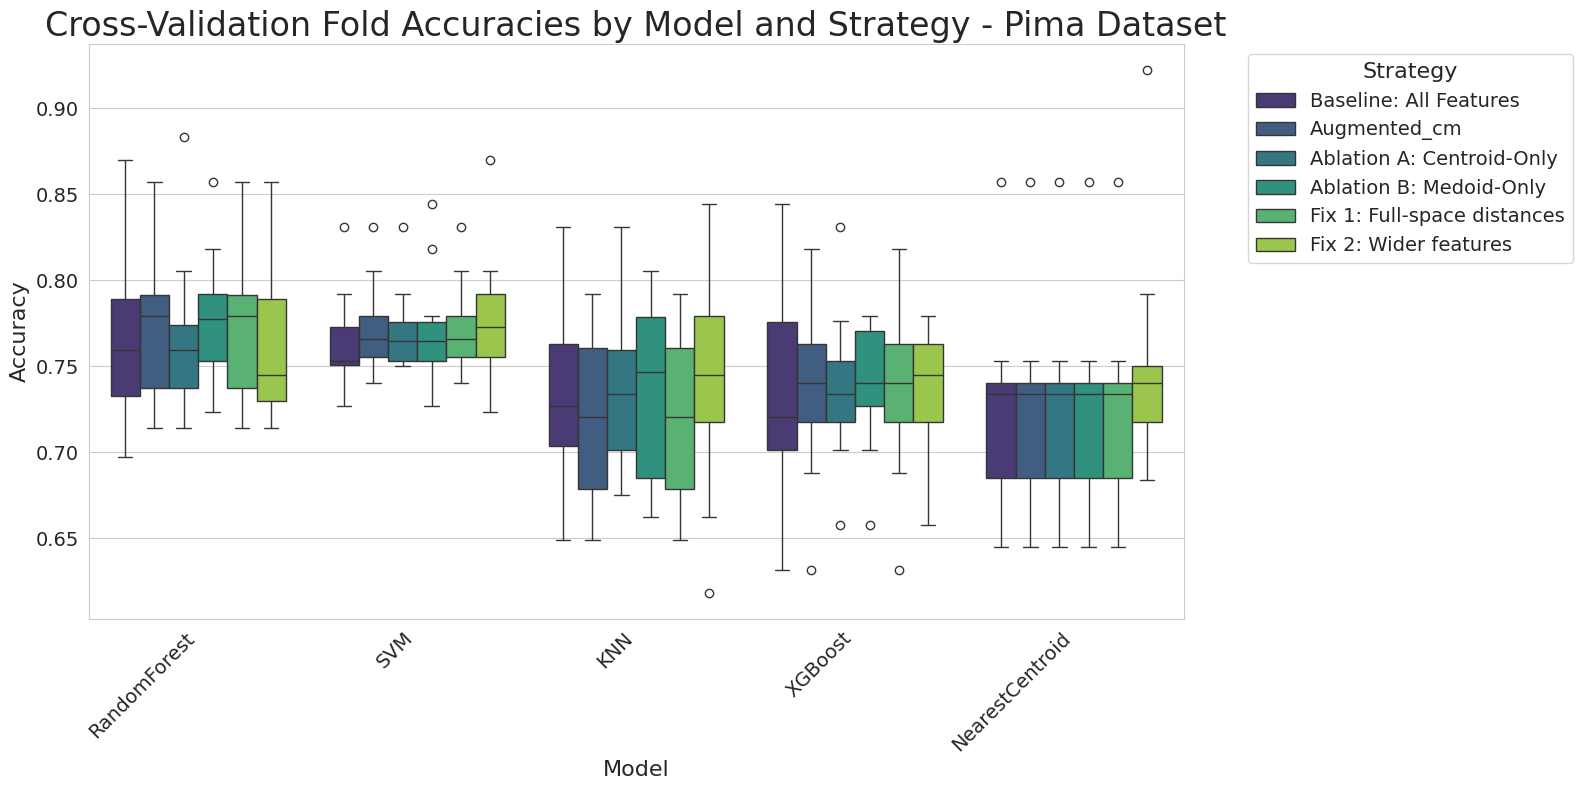

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for boxplot
boxplot_data = []
for result in all_results:
    if '_fold_accuracies' in result:
        model_name = result['Model']
        strategy_name = result['Strategy']
        for acc in result['_fold_accuracies']:
            boxplot_data.append({'Model': model_name, 'Strategy': strategy_name, 'Accuracy': acc})

boxplot_df = pd.DataFrame(boxplot_data)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Create the boxplot
sns.boxplot(data=boxplot_df, x='Model', y='Accuracy', hue='Strategy', palette='viridis')

# Customize plot titles and labels
plt.title('Cross-Validation Fold Accuracies by Model and Strategy - Pima Dataset', fontsize=24)
plt.xlabel('Model', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16)
plt.tight_layout()
plt.show()

Generating Confusion Matrices for each model (using 'Baseline: All Features' strategy)...

Model: RandomForest


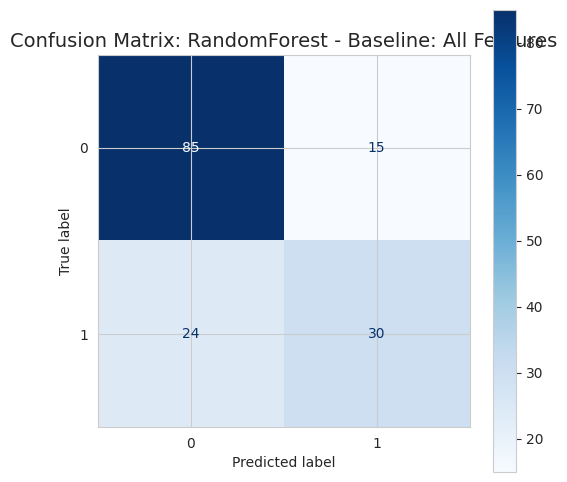


Model: SVM


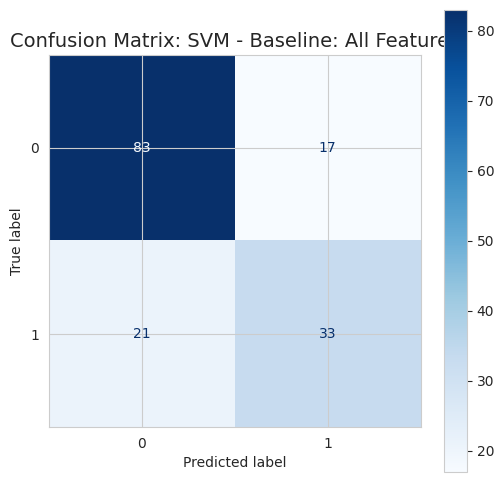


Model: KNN


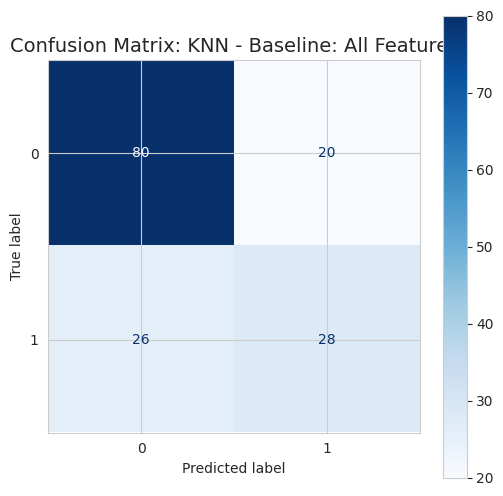


Model: XGBoost


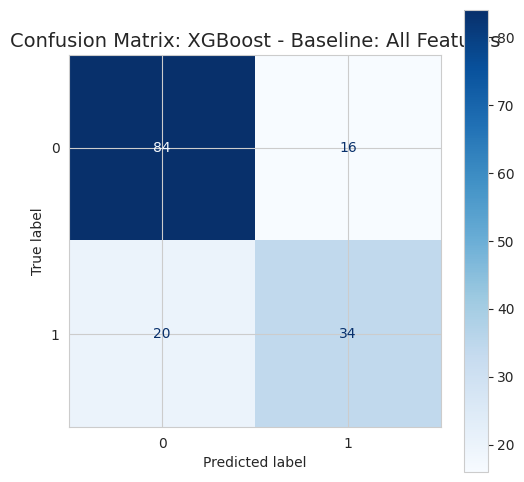


Model: NearestCentroid


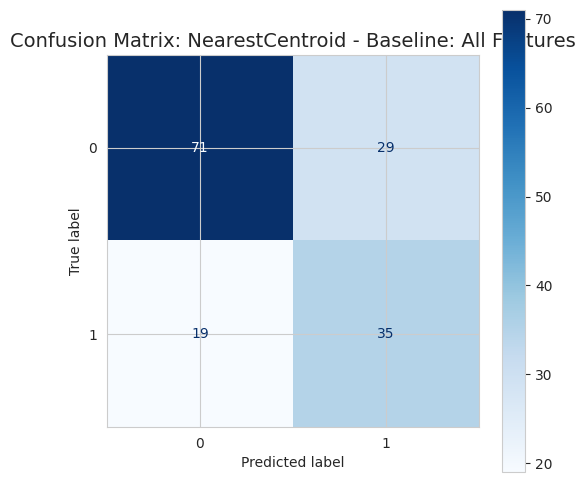

Finished generating confusion matrices.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Assuming X_train, y_train, X_test, y_test, class_names, models_to_evaluate are available from previous cells.

def get_predictions_for_baseline_cm(model_class, model_params, X_tr, y_tr, X_te):
    """
    Trains a model using 'Baseline: All Features' strategy and returns predictions on the test set.
    This specifically uses the full feature set, scaled.
    """
    features = X_tr.columns.tolist()

    # Scale data
    scaler = StandardScaler()
    X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr[features]), columns=features, index=X_tr.index)
    X_te_scaled = pd.DataFrame(scaler.transform(X_te[features]), columns=features, index=X_te.index)

    model = model_class(**model_params)
    model.fit(X_tr_scaled, y_tr)
    return model.predict(X_te_scaled)


# Plot confusion matrix function
def plot_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(title, fontsize=14)
    plt.show()

print("Generating Confusion Matrices for each model (using 'Baseline: All Features' strategy)...")

# Iterate through models to evaluate
for mname, (mcls, mparams) in models_to_evaluate.items():
    print(f"\nModel: {mname}")
    y_pred = get_predictions_for_baseline_cm(mcls, mparams, X_train, y_train, X_test)
    plot_cm(y_test, y_pred, class_names, f'Confusion Matrix: {mname} - Baseline: All Features')

print("Finished generating confusion matrices.")

Generating Confusion Matrices for each model (using 'Augmented_cm' strategy)...

Model: RandomForest


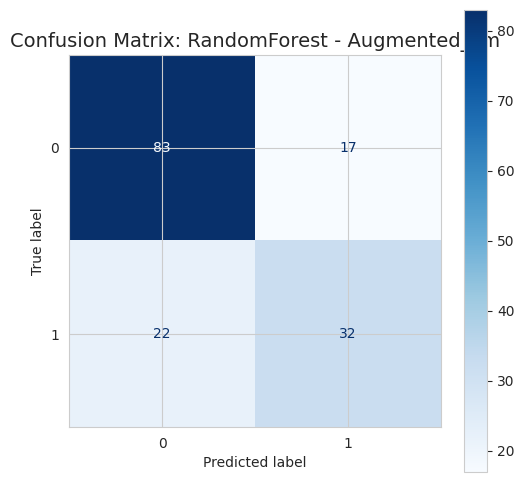


Model: SVM


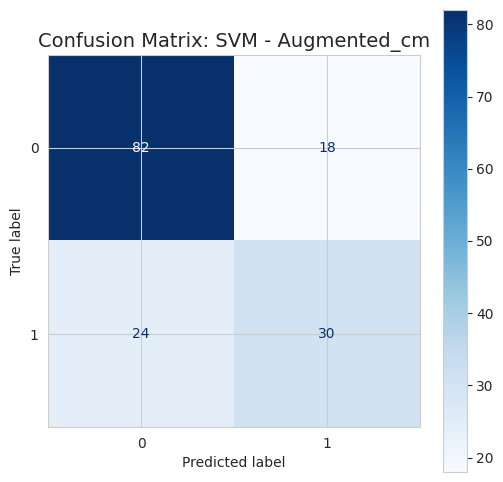


Model: KNN


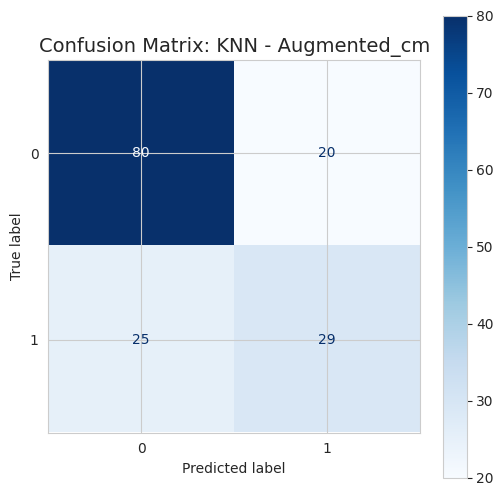


Model: XGBoost


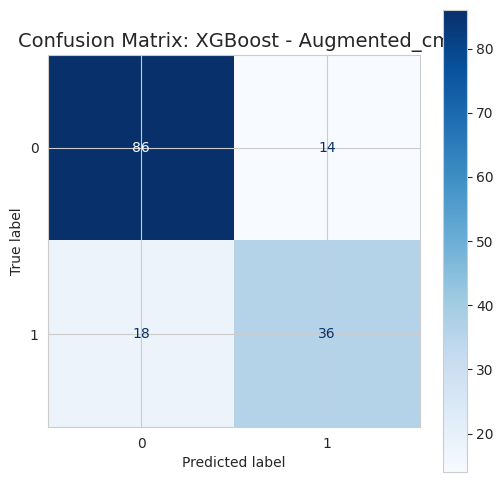


Model: NearestCentroid


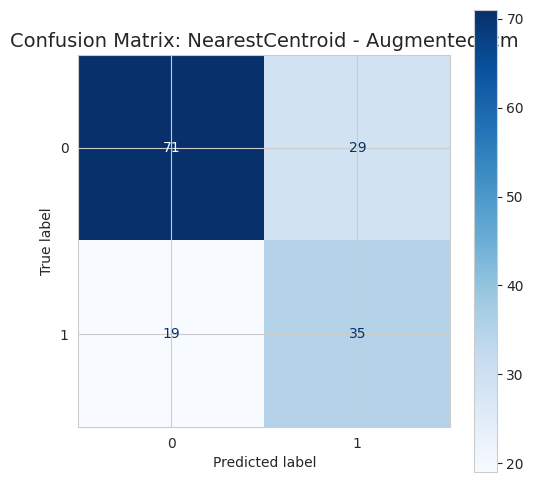

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Re-using plot_cm function from previous cell if available, or redefining for clarity
def plot_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(title, fontsize=14)
    plt.show()

def get_predictions_for_augmented_cm(model_class, model_params, X_tr, y_tr, X_te, class_names, random_state=42):
    """
    Trains a model using 'Augmented_cm' strategy (centroid + medoid distances on filtered features)
    and returns predictions on the test set.
    """
    # Feature selection performed on training data only
    fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=random_state)

    # NearestCentroid does not support augmentation; run plain scaled features
    if model_class.__name__ == 'NearestCentroid':
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
        X_te_sc = scaler.transform(X_te[fold_top_feats])
        model = model_class(**model_params)
        model.fit(X_tr_sc, y_tr)
        return model.predict(X_te_sc)

    scaler = StandardScaler()
    X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                            columns=fold_top_feats, index=X_tr.index)
    X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                            columns=fold_top_feats, index=X_te.index)

    # Centroids and medoids from training data only
    train_sc = X_tr_sc.copy()
    train_sc['Class'] = y_tr
    grouped = train_sc.groupby('Class')
    centroids = grouped[fold_top_feats].mean()
    medoids = pd.DataFrame(
        {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
         for cls, g in grouped}).T

    def augment(X_sc):
        X_aug = X_sc.copy()
        for cls in centroids.index:
            X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
            X_aug[f'dist_medoid_{cls}'] = np.linalg.norm(
                X_sc[fold_top_feats].values - medoids.loc[cls].values, axis=1)
        return X_aug

    X_tr_aug = augment(X_tr_sc)
    X_te_aug = augment(X_te_sc)

    model = model_class(**model_params)
    model.fit(X_tr_aug, y_tr)
    return model.predict(X_te_aug)

print("Generating Confusion Matrices for each model (using 'Augmented_cm' strategy)...")

# Iterate through models to evaluate (assuming models_to_evaluate, X_train, y_train, X_test, y_test, class_names are defined)
for mname, (mcls, mparams) in models_to_evaluate.items():
    print(f"\nModel: {mname}")
    y_pred = get_predictions_for_augmented_cm(mcls, mparams, X_train, y_train, X_test, class_names)
    plot_cm(y_test, y_pred, class_names, f'Confusion Matrix: {mname} - Augmented_cm')